In [1]:
import sys
sys.path.append("../src")
import numpy as np
import torch
from dataset import NeuralSequenceDataset
from model import NeuralGPT

data = np.load("../data/processed_sub01_ses02.npz")
windows, labels = data["windows"], data["labels"]

ds = NeuralSequenceDataset(windows, labels, seq_len=16)

device = "mps" if torch.backends.mps.is_available() else "cpu"
model = NeuralGPT(n_channels=64, window_samples=50, seq_len=16).to(device)
model.load_state_dict(torch.load("../neural_gpt.pt", map_location=device))
model.eval()

embs = []
labs = []
with torch.no_grad():
    for i in range(len(ds)):
        seq, target, target_label = ds[i]
        seq = seq.unsqueeze(0).to(device)
        emb = model.embed_sequence(seq).cpu().numpy()[0]
        embs.append(emb)
        labs.append(target_label.item())

embs = np.array(embs)
labs = np.array(labs)
print(embs.shape, labs.shape, labs.mean())

(2168, 128) (2168,) 0.16512915129151293


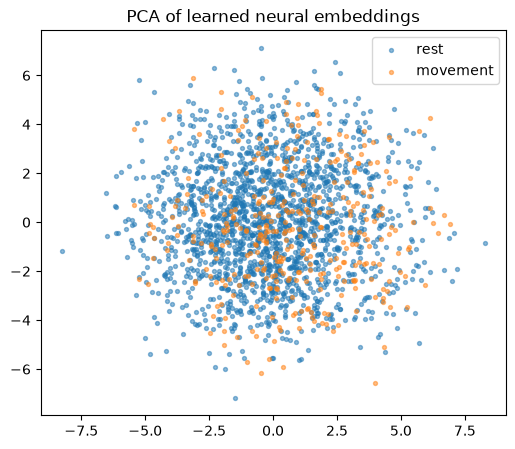

In [4]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, silhouette_score
import matplotlib.pyplot as plt

pca_proj = PCA(n_components=2).fit_transform(embs)

plt.figure(figsize=(6, 5))
plt.scatter(pca_proj[labs == 0, 0], pca_proj[labs == 0, 1], s=8, alpha=0.5, label="rest")
plt.scatter(pca_proj[labs == 1, 0], pca_proj[labs == 1, 1], s=8, alpha=0.5, label="movement")
plt.legend()
plt.title("PCA of learned neural embeddings")
plt.show()

In [5]:
X_train, X_test, y_train, y_test = train_test_split(embs, labs, test_size=0.3, stratify=labs, random_state=0)
clf = LogisticRegression(max_iter=1000).fit(X_train, y_train)
acc = accuracy_score(y_test, clf.predict(X_test))
sil = silhouette_score(embs, labs)

print("linear probe accuracy:", acc)
print("silhouette score:", sil)
print("baseline (always predict rest):", 1 - labs.mean())

linear probe accuracy: 0.8218125960061444
silhouette score: 0.002089609857648611
baseline (always predict rest): 0.834870848708487


In [7]:
from scipy.signal import welch
from scipy.stats import mannwhitneyu
import numpy as np

band_powers = []
for w in windows:
    freqs, psd = welch(w, fs=250, axis=-1, nperseg=50)
    gamma_mask = (freqs >= 70) & (freqs <= 100)
    gamma_power = psd[:, gamma_mask].mean()
    band_powers.append(gamma_power)

band_powers = np.array(band_powers)

move_power = band_powers[labels[:len(band_powers)] == 1]
rest_power = band_powers[labels[:len(band_powers)] == 0]

print("mean gamma power, movement windows:", move_power.mean())
print("mean gamma power, rest windows:", rest_power.mean())

stat, p = mannwhitneyu(move_power, rest_power)
print("p-value:", p)

mean gamma power, movement windows: 5.995878e-05
mean gamma power, rest windows: 6.0488423e-05
p-value: 3.5391534e-33
